In [32]:
import pandas as pd
from pathlib import Path
from scipy import stats
from scipy.stats import friedmanchisquare
import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [1]:
ensemble_metrics_dir = Path("../../2_final_runs/3_uy_basins/ensemble_testing_metrics") #UY
ensemble_peak_metrics_dir = Path("../../2_final_runs/3_uy_basins/ensemble_peak_metrics") #UY

NameError: name 'Path' is not defined

In [2]:
metric_names = [
    'Peak-MAPE', 'Missed-Peaks', 'Peak-Timing',
    'FLV', 'FMS', 'FHV',
    'Beta-KGE', 'MSE', 'RMSE', 'NSE'
]

In [4]:
# ── Friedman test ─────────────────────────────────────────────────────────────
def friedman_test(df, metric_name):
    data = [df[col].dropna().values for col in df.columns]
    stat, p = friedmanchisquare(*data)

    k = len(df.columns)
    n = len(df)
    W = stat / (n * (k - 1))

    if W < 0.1:
        effect = "negligible"
    elif W < 0.3:
        effect = "small"
    elif W < 0.5:
        effect = "moderate"
    else:
        effect = "large"

    print(f"\n{'='*55}")
    print(f"  Friedman Test — {metric_name}")
    print(f"{'='*55}")
    print(f"  χ²           = {stat:.4f}")
    print(f"  p-value      = {p:.4f}")
    print(f"  Kendall W    = {W:.4f} ({effect} effect)")
    print(f"  n catchments = {n}, k models = {k}")
    print(f"\n  {'Significant difference between models (p < 0.05)' if p < 0.05 else 'No significant difference between models (p >= 0.05)'}")

    return stat, p, W

In [5]:
metric_targets = {
    'Peak-MAPE': 0,
    'Missed-Peaks': 0,
    'Peak-Timing': 0,
    'FLV': 0,
    'FMS': 0,
    'FHV': 0,
    'Mean ratio': 1,   # ← updated here
    'MSE': 0,
    'RMSE': 0,
    'NSE': 1
}

In [6]:
def posthoc_wilcoxon(df, metric_name, friedman_p, metric_targets):
    if friedman_p >= 0.05:
        print(f"\nSkipping post-hoc for {metric_name} — Friedman not significant (p={friedman_p:.4f})")
        return None
    
    models = df.columns.tolist()
    pairs  = list(itertools.combinations(models, 2))
    target = metric_targets[metric_name]
    
    rows = []
    for m1, m2 in pairs:
        diff      = df[m1].values - df[m2].values
        n_zeros   = (diff == 0).sum()
        n_effective = len(diff) - n_zeros

        if n_zeros > 0:
            print(f"  ⚠️  {metric_name} | {m1} vs {m2}: "
                  f"{n_zeros} tied pairs dropped (n_effective={n_effective})")

        stat, p_raw    = wilcoxon(df[m1].values, df[m2].values)
        median_diff    = np.median(diff)          # >0 → m1 tends higher, <0 → m2 tends higher
        median_m1      = df[m1].median()
        median_m2      = df[m2].median()

        # Direction: which model is closer to the target?
        # if abs(median_m1 - target) < abs(median_m2 - target):
        #     better = m1
        # elif abs(median_m2 - target) < abs(median_m1 - target):
        #     better = m2
        # else:
        #     better = 'tie'

        # Direction:
        dist_m1 = abs(median_m1 - target)
        dist_m2 = abs(median_m2 - target)

        if dist_m1 < dist_m2:
            better = m1
        elif dist_m2 < dist_m1:
            better = m2
        else:
            better = 'tie'

        rows.append({
            'model_1':      m1,
            'model_2':      m2,
            'median_m1':    median_m1,
            'median_m2':    median_m2,
            'median_diff':  median_diff,
            'better':       better,
            'p_raw':        p_raw,
            'n_zeros':      n_zeros,
            'n_effective':  n_effective,
        })
    
    results_df = pd.DataFrame(rows)
    
    _, p_corrected, _, _ = multipletests(results_df['p_raw'], method='bonferroni')
    results_df['p_corrected'] = p_corrected
    results_df['significant'] = p_corrected < 0.05

    print(f"\n{'='*80}")
    print(f"  Wilcoxon signed-rank + Bonferroni — {metric_name}  (target = {target})")
    print(f"{'='*80}")
    for _, row in results_df.iterrows():
        if row['significant']:
            sig = f"* {row['better']} better"
        else:
            sig = "  similar"
        zeros = f"  [⚠️  {int(row['n_zeros'])} ties]" if row['n_zeros'] > 0 else ""
        print(f"  {row['model_1']:20s} vs {row['model_2']:20s}  "
              f"med=({row['median_m1']:.3f} | {row['median_m2']:.3f})  "
              f"p_adj={row['p_corrected']:.4f}  {sig}{zeros}")
    
    return results_df

## CARAVAN, CHIRPS, MSWEP, GAUGE, CHIRPS + MSWWEP

In [7]:
# UY
run_configs = [
    ('caravan',     'precip_prcp_mm_day'),
    ('chirps',      'precip_prcp_chirps_mm_day'),
    ('mswep',       'precip_prcp_mswep_mm_day'),
    ('gauge',       'precip_prcp_gauge_mm_day'),
    ('chirps_mswep','precip_prcp_chirps_mm_day_prcp_mswep_mm_day'),
]

model_labels = [label for label, _ in run_configs]
run_metrics  = [run   for _, run   in run_configs]

In [8]:
# model_labels = [
#     'caravan', 'chirps', 'mswep', 'gauge', 'chirps_mswep'
# ]

metric_names = [
    'Peak-MAPE', 'Missed-Peaks', 'Peak-Timing',
    'FLV', 'FMS', 'FHV',
    'Beta-KGE', 'MSE', 'RMSE', 'NSE'
]

In [9]:
# ── Load data ────────────────────────────────────────────────────────────────
all_metrics = {m: [] for m in metric_names}
basins_order = []

for i, run_name in enumerate(run_metrics):
    metrics_csv = pd.read_csv(ensemble_metrics_dir / f"{run_name}.csv")
    peak_metrics_csv = pd.read_csv(ensemble_peak_metrics_dir / f"{run_name}.csv")

    if i == 0:
        basins_order = metrics_csv["basin_id"].values

    # for metric in metric_names:
    #     all_metrics[metric].append(metrics_csv[metric].values)

    for metric in metric_names:
        if metric in ['Missed-Peaks', 'Peak-Timing']:
            all_metrics[metric].append(peak_metrics_csv[metric].values)
        else:
            all_metrics[metric].append(metrics_csv[metric].values)

# ── Build per-metric DataFrames ───────────────────────────────────────────────
metric_dfs = {
    metric: pd.DataFrame(
        dict(zip(model_labels, arrays)),
        index=basins_order
    )
    for metric, arrays in all_metrics.items()
}

# Rename "Beta-KGE" to "Mean ratio"
metric_dfs["Mean ratio"] = metric_dfs.pop("Beta-KGE")

In [10]:
# ── Run for all metrics ───────────────────────────────────────────────────────
results = {}
for metric, df in metric_dfs.items():
    stat, p, W = friedman_test(df, metric)
    results[metric] = {'stat': stat, 'p': p, 'W': W}


  Friedman Test — Peak-MAPE
  χ²           = 27.0400
  p-value      = 0.0000
  Kendall W    = 0.6760 (large effect)
  n catchments = 10, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — Missed-Peaks
  χ²           = 18.3503
  p-value      = 0.0011
  Kendall W    = 0.4588 (moderate effect)
  n catchments = 10, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — Peak-Timing
  χ²           = 6.5000
  p-value      = 0.1648
  Kendall W    = 0.1625 (small effect)
  n catchments = 10, k models = 5

  No significant difference between models (p >= 0.05)

  Friedman Test — FLV
  χ²           = 9.9200
  p-value      = 0.0418
  Kendall W    = 0.2480 (small effect)
  n catchments = 10, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — FMS
  χ²           = 22.8800
  p-value      = 0.0001
  Kendall W    = 0.5720 (large effect)
  n catchments = 10, k models = 5

  Significant difference between model

In [11]:
friedman_ps = {metric: res['p'] for metric, res in results.items()}
friedman_ps

{'Peak-MAPE': np.float64(1.951215427120976e-05),
 'Missed-Peaks': np.float64(0.001053967535747682),
 'Peak-Timing': np.float64(0.1647903832848193),
 'FLV': np.float64(0.04179704988220884),
 'FMS': np.float64(0.00013381090482071433),
 'FHV': np.float64(2.025251422129696e-05),
 'MSE': np.float64(1.0348131642844003e-05),
 'RMSE': np.float64(1.0348131642844003e-05),
 'NSE': np.float64(1.0348131642844003e-05),
 'Mean ratio': np.float64(7.987476059326673e-05)}

In [12]:
# ── Run for all metrics ───────────────────────────────────────────────────────
posthoc_results = {}
for metric, df in metric_dfs.items():
    result = posthoc_wilcoxon(df, metric, friedman_ps[metric], metric_targets)
    if result is not None:
        posthoc_results[metric] = result


  Wilcoxon signed-rank + Bonferroni — Peak-MAPE  (target = 0)
  caravan              vs chirps                med=(62.168 | 46.320)  p_adj=0.0391  * chirps better
  caravan              vs mswep                 med=(62.168 | 50.158)  p_adj=0.0195  * mswep better
  caravan              vs gauge                 med=(62.168 | 42.854)  p_adj=0.0195  * gauge better
  caravan              vs chirps_mswep          med=(62.168 | 42.144)  p_adj=0.0195  * chirps_mswep better
  chirps               vs mswep                 med=(46.320 | 50.158)  p_adj=1.0000    similar
  chirps               vs gauge                 med=(46.320 | 42.854)  p_adj=1.0000    similar
  chirps               vs chirps_mswep          med=(46.320 | 42.144)  p_adj=0.2734    similar
  mswep                vs gauge                 med=(50.158 | 42.854)  p_adj=0.8398    similar
  mswep                vs chirps_mswep          med=(50.158 | 42.144)  p_adj=0.0586    similar
  gauge                vs chirps_mswep          med=(4

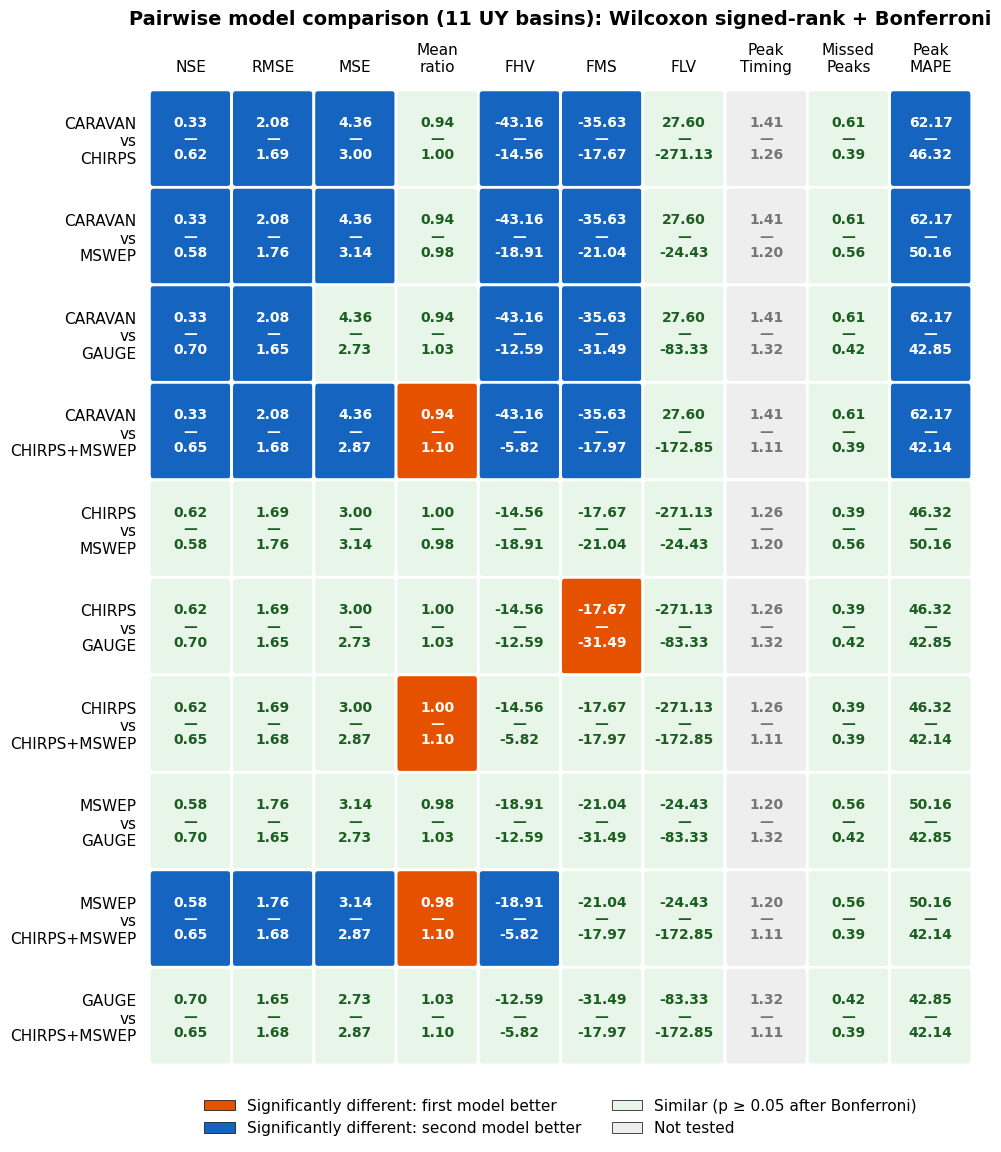

In [13]:
# ── Define models ──────────────────────────────────────────────────────────
models      = ['caravan', 'chirps', 'mswep', 'gauge', 'chirps_mswep']
short_names = ['CARAVAN', 'CHIRPS', 'MSWEP', 'GAUGE', 'CHIRPS+MSWEP']

# ── Helper: get color key from posthoc_results ─────────────────────────────
skipped_metrics = [m for m, p in friedman_ps.items() if p >= 0.05]

def get_color_key(metric, m1, m2):
    res     = posthoc_results[metric]
    row     = res[(res['model_1'] == m1) & (res['model_2'] == m2)]
    flipped = False
    if row.empty:
        row     = res[(res['model_1'] == m2) & (res['model_2'] == m1)]
        flipped = True
    if row.empty:
        return 'tie'
    better = row['better'].values[0]
    if better == 'tie':
        return 'tie'
    if not flipped:
        return 'first'  if better == m1 else 'second'
    else:
        return 'first'  if better == m2 else 'second'

# ── Build plot structures ──────────────────────────────────────────────────

metrics_list = ['NSE', 'RMSE', 'MSE', 'Mean ratio', 'FHV', 'FMS', 'FLV',  
                'Peak-Timing', 'Missed-Peaks', 'Peak-MAPE']

pairs        = list(itertools.combinations(range(len(models)), 2))
pair_labels  = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]
median_vals  = {metric: df.median() for metric, df in metric_dfs.items()}

# ── Colors ─────────────────────────────────────────────────────────────────
colors = {
    0:        '#e8f5e9',
    2:        '#eeeeee',
    'first':  '#e65100',
    'second': '#1565c0',
    'tie':    '#6a1de8',
}
text_colors = {
    0:        '#1b5e20',
    2:        '#757575',
    'first':  'white',
    'second': 'white',
    'tie':    'white',
}

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))
fig.patch.set_facecolor('white')

for m_idx, metric in enumerate(metrics_list):
    for p_idx, (i, j) in enumerate(pairs):
        m1, m2 = models[i], models[j]
        med_i  = median_vals[metric][m1]
        med_j  = median_vals[metric][m2]

        if metric in skipped_metrics:
            color_key = 2                              # Friedman n.s. → grey
        else:
            res    = posthoc_results[metric]
            row    = res[((res['model_1'] == m1) & (res['model_2'] == m2)) |
                         ((res['model_1'] == m2) & (res['model_2'] == m1))]
            is_sig = row['significant'].values[0] if not row.empty else False
            color_key = get_color_key(metric, m1, m2) if is_sig else 0

        rect = mpatches.FancyBboxPatch(
            # (p_idx - 0.45, m_idx - 0.45), 0.9, 0.9,
            (m_idx - 0.45, p_idx - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=colors[color_key],
            edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)

        label = f"{med_i:.2f}\n—\n{med_j:.2f}"
        ax.text(m_idx, p_idx, label,
                ha='center', va='center',
                fontsize=10, color=text_colors[color_key],
                fontweight='bold')


ax.set_xlim(-0.6, len(metrics_list) - 0.4)  
ax.set_ylim(len(pairs) - 0.4, -0.6)   
ax.set_xticks(range(len(metrics_list)))

metrics_list_names = ['NSE', 'RMSE', 'MSE', 'Mean\nratio', 'FHV', 'FMS', 'FLV',  
                'Peak\nTiming', 'Missed\nPeaks', 'Peak\nMAPE']

ax.set_xticklabels(metrics_list_names, fontsize=11) 
ax.set_yticks(range(len(pairs)))         
ax.set_yticklabels(pair_labels, fontsize=11)

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(facecolor=colors['first'],  label='Significantly different: first model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors['second'], label='Significantly different: second model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors[0],        label='Similar (p ≥ 0.05 after Bonferroni)', edgecolor='black',  linewidth=0.5),
    mpatches.Patch(facecolor=colors[2],        label='Not tested', edgecolor='black',  linewidth=0.5), #not significant
]

ax.set_title(
    'Pairwise model comparison (11 UY basins): Wilcoxon signed-rank + Bonferroni',
    # 'Values show median(model 1) | median(model 2)',
    fontsize=14, pad=40, fontweight='bold'
)
ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.01), ncol=2,
          frameon=False, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.10)
# plt.savefig('wilcoxon_heatmap_us.png', dpi=150, bbox_inches='tight')
plt.show()

# CHIRPS + GAUGES

In [14]:
# UY
run_configs = [
    ('caravan',          'precip_prcp_mm_day'),
    ('chirps',           'precip_prcp_chirps_mm_day'),
    ('mswep',            'precip_prcp_mswep_mm_day'),
    ('gauge',            'precip_prcp_gauge_mm_day'),
    ('chirps_mswep',     'precip_prcp_chirps_mm_day_prcp_mswep_mm_day'),
    ('chirps_gauge','precip_prcp_chirps_mm_day_prcp_gauge_mm_day'),
]

model_labels = [label for label, _ in run_configs]
run_metrics  = [run   for _, run   in run_configs]

In [15]:
# ── Load data ────────────────────────────────────────────────────────────────
all_metrics = {m: [] for m in metric_names}
basins_order = []

for i, run_name in enumerate(run_metrics):
    metrics_csv = pd.read_csv(ensemble_metrics_dir / f"{run_name}.csv")
    peak_metrics_csv = pd.read_csv(ensemble_peak_metrics_dir / f"{run_name}.csv")

    if i == 0:
        basins_order = metrics_csv["basin_id"].values

    # for metric in metric_names:
    #     all_metrics[metric].append(metrics_csv[metric].values)

    for metric in metric_names:
        if metric in ['Missed-Peaks', 'Peak-Timing']:
            all_metrics[metric].append(peak_metrics_csv[metric].values)
        else:
            all_metrics[metric].append(metrics_csv[metric].values)

# ── Build per-metric DataFrames ───────────────────────────────────────────────
metric_dfs = {
    metric: pd.DataFrame(
        dict(zip(model_labels, arrays)),
        index=basins_order
    )
    for metric, arrays in all_metrics.items()
}

# Rename "Beta-KGE" to "Mean ratio"
metric_dfs["Mean ratio"] = metric_dfs.pop("Beta-KGE")

In [16]:
# ── Run for all metrics ───────────────────────────────────────────────────────
results = {}
for metric, df in metric_dfs.items():
    stat, p, W = friedman_test(df, metric)
    results[metric] = {'stat': stat, 'p': p, 'W': W}


  Friedman Test — Peak-MAPE
  χ²           = 35.5429
  p-value      = 0.0000
  Kendall W    = 0.7109 (large effect)
  n catchments = 10, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — Missed-Peaks
  χ²           = 27.1746
  p-value      = 0.0001
  Kendall W    = 0.5435 (large effect)
  n catchments = 10, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — Peak-Timing
  χ²           = 8.3333
  p-value      = 0.1388
  Kendall W    = 0.1667 (small effect)
  n catchments = 10, k models = 6

  No significant difference between models (p >= 0.05)

  Friedman Test — FLV
  χ²           = 12.1143
  p-value      = 0.0333
  Kendall W    = 0.2423 (small effect)
  n catchments = 10, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — FMS
  χ²           = 32.8000
  p-value      = 0.0000
  Kendall W    = 0.6560 (large effect)
  n catchments = 10, k models = 6

  Significant difference between models 

In [17]:
friedman_ps = {metric: res['p'] for metric, res in results.items()}
friedman_ps

{'Peak-MAPE': np.float64(1.1722785692255484e-06),
 'Missed-Peaks': np.float64(5.2745463322237134e-05),
 'Peak-Timing': np.float64(0.1387966276653022),
 'FLV': np.float64(0.03325491883393523),
 'FMS': np.float64(4.123693177005279e-06),
 'FHV': np.float64(3.874294110818654e-07),
 'MSE': np.float64(1.2035061645648699e-06),
 'RMSE': np.float64(1.2035061645648699e-06),
 'NSE': np.float64(1.2035061645648699e-06),
 'Mean ratio': np.float64(1.400397912709822e-05)}

In [18]:
# ── Run for all metrics ───────────────────────────────────────────────────────
posthoc_results = {}
for metric, df in metric_dfs.items():
    result = posthoc_wilcoxon(df, metric, friedman_ps[metric], metric_targets)
    if result is not None:
        posthoc_results[metric] = result


  Wilcoxon signed-rank + Bonferroni — Peak-MAPE  (target = 0)
  caravan              vs chirps                med=(62.168 | 46.320)  p_adj=0.0586    similar
  caravan              vs mswep                 med=(62.168 | 50.158)  p_adj=0.0293  * mswep better
  caravan              vs gauge                 med=(62.168 | 42.854)  p_adj=0.0293  * gauge better
  caravan              vs chirps_mswep          med=(62.168 | 42.144)  p_adj=0.0293  * chirps_mswep better
  caravan              vs chirps_gauge          med=(62.168 | 35.005)  p_adj=0.0293  * chirps_gauge better
  chirps               vs mswep                 med=(46.320 | 50.158)  p_adj=1.0000    similar
  chirps               vs gauge                 med=(46.320 | 42.854)  p_adj=1.0000    similar
  chirps               vs chirps_mswep          med=(46.320 | 42.144)  p_adj=0.4102    similar
  chirps               vs chirps_gauge          med=(46.320 | 35.005)  p_adj=0.0879    similar
  mswep                vs gauge                 

  ⚠️  Missed-Peaks | chirps vs gauge: 2 tied pairs dropped (n_effective=8)
  ⚠️  Missed-Peaks | chirps vs chirps_mswep: 4 tied pairs dropped (n_effective=6)
  ⚠️  Missed-Peaks | chirps vs chirps_gauge: 4 tied pairs dropped (n_effective=6)
  ⚠️  Missed-Peaks | mswep vs chirps_mswep: 3 tied pairs dropped (n_effective=7)
  ⚠️  Missed-Peaks | mswep vs chirps_gauge: 1 tied pairs dropped (n_effective=9)
  ⚠️  Missed-Peaks | gauge vs chirps_mswep: 2 tied pairs dropped (n_effective=8)
  ⚠️  Missed-Peaks | gauge vs chirps_gauge: 2 tied pairs dropped (n_effective=8)
  ⚠️  Missed-Peaks | chirps_mswep vs chirps_gauge: 1 tied pairs dropped (n_effective=9)

  Wilcoxon signed-rank + Bonferroni — Missed-Peaks  (target = 0)
  caravan              vs chirps                med=(0.613 | 0.394)  p_adj=0.4102    similar
  caravan              vs mswep                 med=(0.613 | 0.558)  p_adj=1.0000    similar  [⚠️  3 ties]
  caravan              vs gauge                 med=(0.613 | 0.417)  p_adj=0.5566  

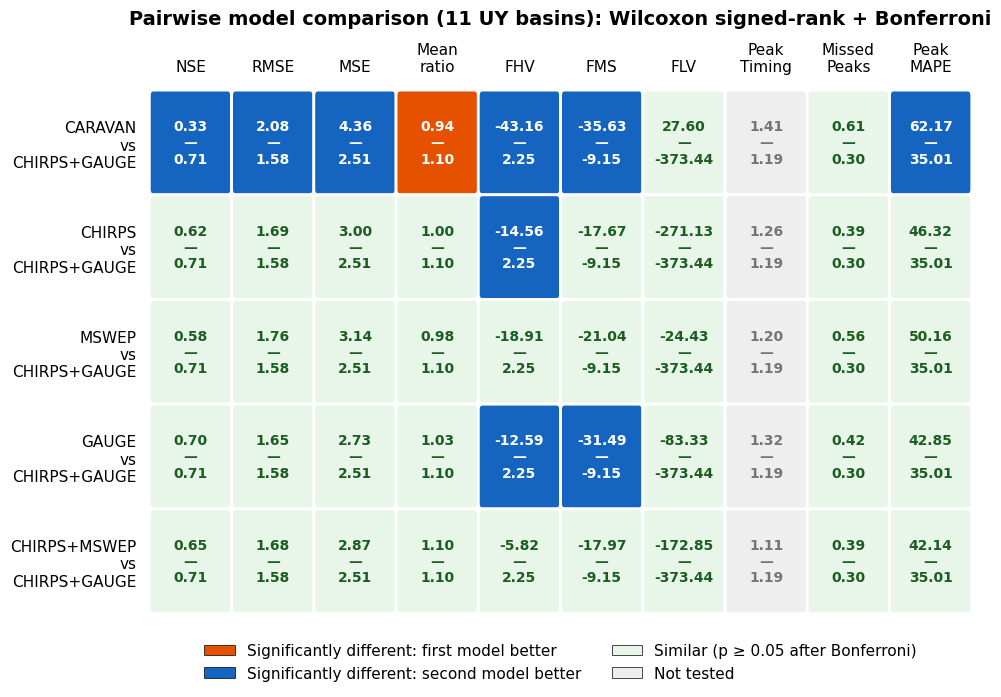

In [19]:
# ── Define models ──────────────────────────────────────────────────────────
models      = ['caravan', 'chirps', 'mswep', 'gauge', 'chirps_mswep', 'chirps_gauge']
short_names = ['CARAVAN', 'CHIRPS', 'MSWEP', 'GAUGE', 'CHIRPS+MSWEP', 'CHIRPS+GAUGE']

# ── Helper: get color key from posthoc_results ─────────────────────────────
skipped_metrics = [m for m, p in friedman_ps.items() if p >= 0.05]

def get_color_key(metric, m1, m2):
    res     = posthoc_results[metric]
    row     = res[(res['model_1'] == m1) & (res['model_2'] == m2)]
    flipped = False
    if row.empty:
        row     = res[(res['model_1'] == m2) & (res['model_2'] == m1)]
        flipped = True
    if row.empty:
        return 'tie'
    better = row['better'].values[0]
    if better == 'tie':
        return 'tie'
    if not flipped:
        return 'first'  if better == m1 else 'second'
    else:
        return 'first'  if better == m2 else 'second'

# ── Build plot structures ──────────────────────────────────────────────────

metrics_list = ['NSE', 'RMSE', 'MSE', 'Mean ratio', 'FHV', 'FMS', 'FLV',  
                'Peak-Timing', 'Missed-Peaks', 'Peak-MAPE']

pairs        = list(itertools.combinations(range(len(models)), 2))

# Keep only pairs involving chirps_mswep_gauge
gauge_idx = models.index('chirps_gauge')
pairs = [(i, j) for i, j in pairs if i == gauge_idx or j == gauge_idx]

pair_labels = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]


pair_labels  = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]
median_vals  = {metric: df.median() for metric, df in metric_dfs.items()}

# ── Colors ─────────────────────────────────────────────────────────────────
colors = {
    0:        '#e8f5e9',
    2:        '#eeeeee',
    'first':  '#e65100',
    'second': '#1565c0',
    'tie':    '#6a1de8',
}
text_colors = {
    0:        '#1b5e20',
    2:        '#757575',
    'first':  'white',
    'second': 'white',
    'tie':    'white',
}

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')

for m_idx, metric in enumerate(metrics_list):
    for p_idx, (i, j) in enumerate(pairs):
        m1, m2 = models[i], models[j]
        med_i  = median_vals[metric][m1]
        med_j  = median_vals[metric][m2]

        if metric in skipped_metrics:
            color_key = 2                              # Friedman n.s. → grey
        else:
            res    = posthoc_results[metric]
            row    = res[((res['model_1'] == m1) & (res['model_2'] == m2)) |
                         ((res['model_1'] == m2) & (res['model_2'] == m1))]
            is_sig = row['significant'].values[0] if not row.empty else False
            color_key = get_color_key(metric, m1, m2) if is_sig else 0

        rect = mpatches.FancyBboxPatch(
            # (p_idx - 0.45, m_idx - 0.45), 0.9, 0.9,
            (m_idx - 0.45, p_idx - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=colors[color_key],
            edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)

        label = f"{med_i:.2f}\n—\n{med_j:.2f}"
        ax.text(m_idx, p_idx, label,
                ha='center', va='center',
                fontsize=10, color=text_colors[color_key],
                fontweight='bold')


ax.set_xlim(-0.6, len(metrics_list) - 0.4)  
ax.set_ylim(len(pairs) - 0.4, -0.6)   
ax.set_xticks(range(len(metrics_list)))

metrics_list_names = ['NSE', 'RMSE', 'MSE', 'Mean\nratio', 'FHV', 'FMS', 'FLV',  
                'Peak\nTiming', 'Missed\nPeaks', 'Peak\nMAPE']

ax.set_xticklabels(metrics_list_names, fontsize=11) 
ax.set_yticks(range(len(pairs)))        
ax.set_yticklabels(pair_labels, fontsize=11)

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(facecolor=colors['first'],  label='Significantly different: first model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors['second'], label='Significantly different: second model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors[0],        label='Similar (p ≥ 0.05 after Bonferroni)', edgecolor='black',  linewidth=0.5),
    mpatches.Patch(facecolor=colors[2],        label='Not tested', edgecolor='black',  linewidth=0.5), #not significant
]

ax.set_title(
    'Pairwise model comparison (11 UY basins): Wilcoxon signed-rank + Bonferroni',
    # 'Values show median(model 1) | median(model 2)',
    fontsize=14, pad=40, fontweight='bold'
)
ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.01), ncol=2,
          frameon=False, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.10)
# plt.savefig('wilcoxon_heatmap_us.png', dpi=150, bbox_inches='tight')
plt.show()

# MSWEP + GAUGES

In [20]:
# UY
run_configs = [
    ('caravan',          'precip_prcp_mm_day'),
    ('chirps',           'precip_prcp_chirps_mm_day'),
    ('mswep',            'precip_prcp_mswep_mm_day'),
    ('gauge',            'precip_prcp_gauge_mm_day'),
    ('chirps_mswep',     'precip_prcp_chirps_mm_day_prcp_mswep_mm_day'),
    ('mswep_gauge','precip_prcp_mswep_mm_day_prcp_gauge_mm_day'),
]

model_labels = [label for label, _ in run_configs]
run_metrics  = [run   for _, run   in run_configs]

In [21]:
# ── Load data ────────────────────────────────────────────────────────────────
all_metrics = {m: [] for m in metric_names}
basins_order = []

for i, run_name in enumerate(run_metrics):
    metrics_csv = pd.read_csv(ensemble_metrics_dir / f"{run_name}.csv")
    peak_metrics_csv = pd.read_csv(ensemble_peak_metrics_dir / f"{run_name}.csv")

    if i == 0:
        basins_order = metrics_csv["basin_id"].values

    # for metric in metric_names:
    #     all_metrics[metric].append(metrics_csv[metric].values)

    for metric in metric_names:
        if metric in ['Missed-Peaks', 'Peak-Timing']:
            all_metrics[metric].append(peak_metrics_csv[metric].values)
        else:
            all_metrics[metric].append(metrics_csv[metric].values)

# ── Build per-metric DataFrames ───────────────────────────────────────────────
metric_dfs = {
    metric: pd.DataFrame(
        dict(zip(model_labels, arrays)),
        index=basins_order
    )
    for metric, arrays in all_metrics.items()
}

# Rename "Beta-KGE" to "Mean ratio"
metric_dfs["Mean ratio"] = metric_dfs.pop("Beta-KGE")

In [22]:
# ── Run for all metrics ───────────────────────────────────────────────────────
results = {}
for metric, df in metric_dfs.items():
    stat, p, W = friedman_test(df, metric)
    results[metric] = {'stat': stat, 'p': p, 'W': W}


  Friedman Test — Peak-MAPE
  χ²           = 33.4286
  p-value      = 0.0000
  Kendall W    = 0.6686 (large effect)
  n catchments = 10, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — Missed-Peaks
  χ²           = 21.7857
  p-value      = 0.0006
  Kendall W    = 0.4357 (moderate effect)
  n catchments = 10, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — Peak-Timing
  χ²           = 10.1389
  p-value      = 0.0714
  Kendall W    = 0.2028 (small effect)
  n catchments = 10, k models = 6

  No significant difference between models (p >= 0.05)

  Friedman Test — FLV
  χ²           = 9.9429
  p-value      = 0.0769
  Kendall W    = 0.1989 (small effect)
  n catchments = 10, k models = 6

  No significant difference between models (p >= 0.05)

  Friedman Test — FMS
  χ²           = 29.7714
  p-value      = 0.0000
  Kendall W    = 0.5954 (large effect)
  n catchments = 10, k models = 6

  Significant difference between 

In [23]:
friedman_ps = {metric: res['p'] for metric, res in results.items()}
friedman_ps

{'Peak-MAPE': np.float64(3.093406341049202e-06),
 'Missed-Peaks': np.float64(0.0005750517373517324),
 'Peak-Timing': np.float64(0.07139419271118178),
 'FLV': np.float64(0.07687064979658191),
 'FMS': np.float64(1.6357727183505858e-05),
 'FHV': np.float64(2.509047003174496e-06),
 'MSE': np.float64(3.618781823236156e-06),
 'RMSE': np.float64(3.618781823236156e-06),
 'NSE': np.float64(3.618781823236156e-06),
 'Mean ratio': np.float64(7.655941308588304e-05)}

In [24]:
# ── Run for all metrics ───────────────────────────────────────────────────────
posthoc_results = {}
for metric, df in metric_dfs.items():
    result = posthoc_wilcoxon(df, metric, friedman_ps[metric], metric_targets)
    if result is not None:
        posthoc_results[metric] = result


  Wilcoxon signed-rank + Bonferroni — Peak-MAPE  (target = 0)
  caravan              vs chirps                med=(62.168 | 46.320)  p_adj=0.0586    similar
  caravan              vs mswep                 med=(62.168 | 50.158)  p_adj=0.0293  * mswep better
  caravan              vs gauge                 med=(62.168 | 42.854)  p_adj=0.0293  * gauge better
  caravan              vs chirps_mswep          med=(62.168 | 42.144)  p_adj=0.0293  * chirps_mswep better
  caravan              vs mswep_gauge           med=(62.168 | 39.821)  p_adj=0.0293  * mswep_gauge better
  chirps               vs mswep                 med=(46.320 | 50.158)  p_adj=1.0000    similar
  chirps               vs gauge                 med=(46.320 | 42.854)  p_adj=1.0000    similar
  chirps               vs chirps_mswep          med=(46.320 | 42.144)  p_adj=0.4102    similar
  chirps               vs mswep_gauge           med=(46.320 | 39.821)  p_adj=0.4102    similar
  mswep                vs gauge                 m

  ⚠️  Missed-Peaks | mswep vs chirps_mswep: 3 tied pairs dropped (n_effective=7)
  ⚠️  Missed-Peaks | mswep vs mswep_gauge: 3 tied pairs dropped (n_effective=7)
  ⚠️  Missed-Peaks | gauge vs chirps_mswep: 2 tied pairs dropped (n_effective=8)
  ⚠️  Missed-Peaks | gauge vs mswep_gauge: 3 tied pairs dropped (n_effective=7)
  ⚠️  Missed-Peaks | chirps_mswep vs mswep_gauge: 3 tied pairs dropped (n_effective=7)

  Wilcoxon signed-rank + Bonferroni — Missed-Peaks  (target = 0)
  caravan              vs chirps                med=(0.613 | 0.394)  p_adj=0.4102    similar
  caravan              vs mswep                 med=(0.613 | 0.558)  p_adj=1.0000    similar  [⚠️  3 ties]
  caravan              vs gauge                 med=(0.613 | 0.417)  p_adj=0.5566    similar
  caravan              vs chirps_mswep          med=(0.613 | 0.390)  p_adj=0.1758    similar  [⚠️  1 ties]
  caravan              vs mswep_gauge           med=(0.613 | 0.396)  p_adj=0.0293  * mswep_gauge better
  chirps             

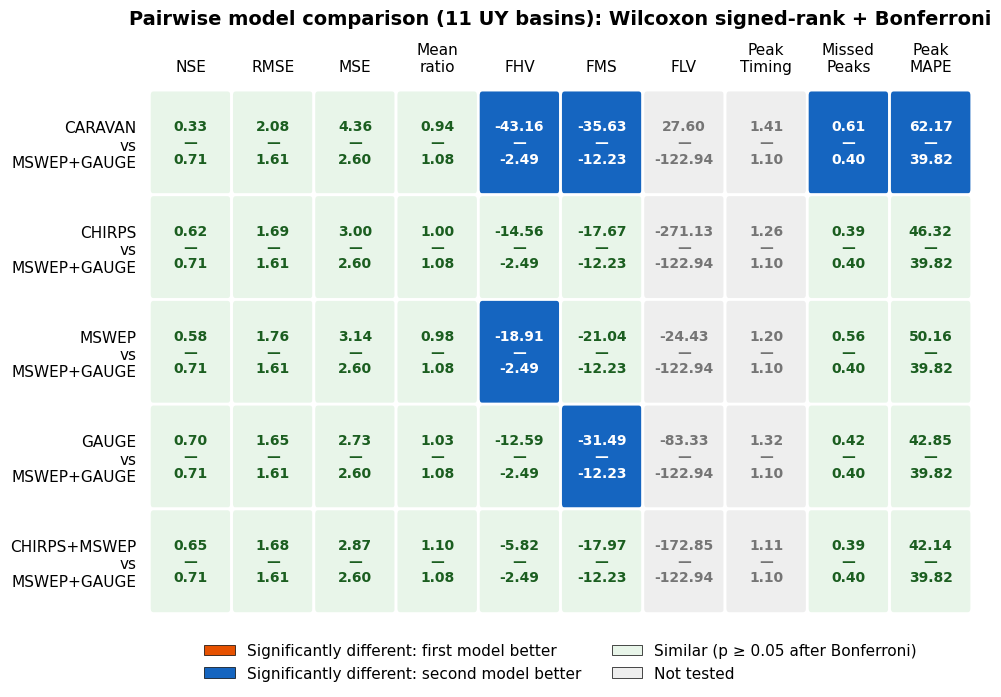

In [25]:
# ── Define models ──────────────────────────────────────────────────────────
models      = ['caravan', 'chirps', 'mswep', 'gauge', 'chirps_mswep', 'mswep_gauge']
short_names = ['CARAVAN', 'CHIRPS', 'MSWEP', 'GAUGE', 'CHIRPS+MSWEP', 'MSWEP+GAUGE']

# ── Helper: get color key from posthoc_results ─────────────────────────────
skipped_metrics = [m for m, p in friedman_ps.items() if p >= 0.05]

def get_color_key(metric, m1, m2):
    res     = posthoc_results[metric]
    row     = res[(res['model_1'] == m1) & (res['model_2'] == m2)]
    flipped = False
    if row.empty:
        row     = res[(res['model_1'] == m2) & (res['model_2'] == m1)]
        flipped = True
    if row.empty:
        return 'tie'
    better = row['better'].values[0]
    if better == 'tie':
        return 'tie'
    if not flipped:
        return 'first'  if better == m1 else 'second'
    else:
        return 'first'  if better == m2 else 'second'

# ── Build plot structures ──────────────────────────────────────────────────

metrics_list = ['NSE', 'RMSE', 'MSE', 'Mean ratio', 'FHV', 'FMS', 'FLV',  
                'Peak-Timing', 'Missed-Peaks', 'Peak-MAPE']

pairs        = list(itertools.combinations(range(len(models)), 2))

# Keep only pairs involving chirps_mswep_gauge
gauge_idx = models.index('mswep_gauge')
pairs = [(i, j) for i, j in pairs if i == gauge_idx or j == gauge_idx]

pair_labels = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]


pair_labels  = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]
median_vals  = {metric: df.median() for metric, df in metric_dfs.items()}

# ── Colors ─────────────────────────────────────────────────────────────────
colors = {
    0:        '#e8f5e9',
    2:        '#eeeeee',
    'first':  '#e65100',
    'second': '#1565c0',
    'tie':    '#6a1de8',
}
text_colors = {
    0:        '#1b5e20',
    2:        '#757575',
    'first':  'white',
    'second': 'white',
    'tie':    'white',
}

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')

for m_idx, metric in enumerate(metrics_list):
    for p_idx, (i, j) in enumerate(pairs):
        m1, m2 = models[i], models[j]
        med_i  = median_vals[metric][m1]
        med_j  = median_vals[metric][m2]

        if metric in skipped_metrics:
            color_key = 2                              # Friedman n.s. → grey
        else:
            res    = posthoc_results[metric]
            row    = res[((res['model_1'] == m1) & (res['model_2'] == m2)) |
                         ((res['model_1'] == m2) & (res['model_2'] == m1))]
            is_sig = row['significant'].values[0] if not row.empty else False
            color_key = get_color_key(metric, m1, m2) if is_sig else 0

        rect = mpatches.FancyBboxPatch(
            # (p_idx - 0.45, m_idx - 0.45), 0.9, 0.9,
            (m_idx - 0.45, p_idx - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=colors[color_key],
            edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)

        label = f"{med_i:.2f}\n—\n{med_j:.2f}"
        ax.text(m_idx, p_idx, label,
                ha='center', va='center',
                fontsize=10, color=text_colors[color_key],
                fontweight='bold')


ax.set_xlim(-0.6, len(metrics_list) - 0.4)  
ax.set_ylim(len(pairs) - 0.4, -0.6)   
ax.set_xticks(range(len(metrics_list)))

metrics_list_names = ['NSE', 'RMSE', 'MSE', 'Mean\nratio', 'FHV', 'FMS', 'FLV',  
                'Peak\nTiming', 'Missed\nPeaks', 'Peak\nMAPE']

ax.set_xticklabels(metrics_list_names, fontsize=11) 
ax.set_yticks(range(len(pairs)))        
ax.set_yticklabels(pair_labels, fontsize=11)

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(facecolor=colors['first'],  label='Significantly different: first model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors['second'], label='Significantly different: second model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors[0],        label='Similar (p ≥ 0.05 after Bonferroni)', edgecolor='black',  linewidth=0.5),
    mpatches.Patch(facecolor=colors[2],        label='Not tested', edgecolor='black',  linewidth=0.5), #not significant
]

ax.set_title(
    'Pairwise model comparison (11 UY basins): Wilcoxon signed-rank + Bonferroni',
    # 'Values show median(model 1) | median(model 2)',
    fontsize=14, pad=40, fontweight='bold'
)
ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.01), ncol=2,
          frameon=False, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.10)
# plt.savefig('wilcoxon_heatmap_us.png', dpi=150, bbox_inches='tight')

# CHIRPS + MSWEP + GAUGE

In [26]:
# UY
run_configs = [
    ('caravan',          'precip_prcp_mm_day'),
    ('chirps',           'precip_prcp_chirps_mm_day'),
    ('mswep',            'precip_prcp_mswep_mm_day'),
    ('gauge',            'precip_prcp_gauge_mm_day'),
    ('chirps_mswep',     'precip_prcp_chirps_mm_day_prcp_mswep_mm_day'),
    # ('chirps_gauge','precip_prcp_chirps_mm_day_prcp_gauge_mm_day'),
    # ('mswep_gauge','precip_prcp_mswep_mm_day_prcp_gauge_mm_day'),
    ('chirps_mswep_gauge','precip_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day'),
]

model_labels = [label for label, _ in run_configs]
run_metrics  = [run   for _, run   in run_configs]

In [27]:
# ── Load data ────────────────────────────────────────────────────────────────
all_metrics = {m: [] for m in metric_names}
basins_order = []

for i, run_name in enumerate(run_metrics):
    metrics_csv = pd.read_csv(ensemble_metrics_dir / f"{run_name}.csv")
    peak_metrics_csv = pd.read_csv(ensemble_peak_metrics_dir / f"{run_name}.csv")

    if i == 0:
        basins_order = metrics_csv["basin_id"].values

    # for metric in metric_names:
    #     all_metrics[metric].append(metrics_csv[metric].values)

    for metric in metric_names:
        if metric in ['Missed-Peaks', 'Peak-Timing']:
            all_metrics[metric].append(peak_metrics_csv[metric].values)
        else:
            all_metrics[metric].append(metrics_csv[metric].values)

# ── Build per-metric DataFrames ───────────────────────────────────────────────
metric_dfs = {
    metric: pd.DataFrame(
        dict(zip(model_labels, arrays)),
        index=basins_order
    )
    for metric, arrays in all_metrics.items()
}

# Rename "Beta-KGE" to "Mean ratio"
metric_dfs["Mean ratio"] = metric_dfs.pop("Beta-KGE")

In [28]:
# ── Run for all metrics ───────────────────────────────────────────────────────
results = {}
for metric, df in metric_dfs.items():
    stat, p, W = friedman_test(df, metric)
    results[metric] = {'stat': stat, 'p': p, 'W': W}


  Friedman Test — Peak-MAPE
  χ²           = 32.6857
  p-value      = 0.0000
  Kendall W    = 0.6537 (large effect)
  n catchments = 10, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — Missed-Peaks
  χ²           = 21.7880
  p-value      = 0.0006
  Kendall W    = 0.4358 (moderate effect)
  n catchments = 10, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — Peak-Timing
  χ²           = 7.3053
  p-value      = 0.1989
  Kendall W    = 0.1461 (small effect)
  n catchments = 10, k models = 6

  No significant difference between models (p >= 0.05)

  Friedman Test — FLV
  χ²           = 13.4857
  p-value      = 0.0192
  Kendall W    = 0.2697 (small effect)
  n catchments = 10, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — FMS
  χ²           = 23.2000
  p-value      = 0.0003
  Kendall W    = 0.4640 (moderate effect)
  n catchments = 10, k models = 6

  Significant difference between m

In [29]:
friedman_ps = {metric: res['p'] for metric, res in results.items()}
friedman_ps

{'Peak-MAPE': np.float64(4.344739325856377e-06),
 'Missed-Peaks': np.float64(0.0005744837848185449),
 'Peak-Timing': np.float64(0.1989070423471268),
 'FLV': np.float64(0.019228328911740877),
 'FMS': np.float64(0.00030910372607717416),
 'FHV': np.float64(3.913830119454642e-06),
 'MSE': np.float64(4.123693177005279e-06),
 'RMSE': np.float64(4.123693177005279e-06),
 'NSE': np.float64(4.123693177005279e-06),
 'Mean ratio': np.float64(2.4732823470110378e-05)}

In [30]:
# ── Run for all metrics ───────────────────────────────────────────────────────
posthoc_results = {}
for metric, df in metric_dfs.items():
    result = posthoc_wilcoxon(df, metric, friedman_ps[metric], metric_targets)
    if result is not None:
        posthoc_results[metric] = result


  Wilcoxon signed-rank + Bonferroni — Peak-MAPE  (target = 0)
  caravan              vs chirps                med=(62.168 | 46.320)  p_adj=0.0586    similar
  caravan              vs mswep                 med=(62.168 | 50.158)  p_adj=0.0293  * mswep better
  caravan              vs gauge                 med=(62.168 | 42.854)  p_adj=0.0293  * gauge better
  caravan              vs chirps_mswep          med=(62.168 | 42.144)  p_adj=0.0293  * chirps_mswep better
  caravan              vs chirps_mswep_gauge    med=(62.168 | 40.010)  p_adj=0.0293  * chirps_mswep_gauge better
  chirps               vs mswep                 med=(46.320 | 50.158)  p_adj=1.0000    similar
  chirps               vs gauge                 med=(46.320 | 42.854)  p_adj=1.0000    similar
  chirps               vs chirps_mswep          med=(46.320 | 42.144)  p_adj=0.4102    similar
  chirps               vs chirps_mswep_gauge    med=(46.320 | 40.010)  p_adj=0.4102    similar
  mswep                vs gauge           

  ⚠️  Missed-Peaks | chirps vs chirps_mswep: 4 tied pairs dropped (n_effective=6)
  ⚠️  Missed-Peaks | chirps vs chirps_mswep_gauge: 4 tied pairs dropped (n_effective=6)
  ⚠️  Missed-Peaks | mswep vs chirps_mswep: 3 tied pairs dropped (n_effective=7)
  ⚠️  Missed-Peaks | mswep vs chirps_mswep_gauge: 2 tied pairs dropped (n_effective=8)
  ⚠️  Missed-Peaks | gauge vs chirps_mswep: 2 tied pairs dropped (n_effective=8)
  ⚠️  Missed-Peaks | gauge vs chirps_mswep_gauge: 2 tied pairs dropped (n_effective=8)
  ⚠️  Missed-Peaks | chirps_mswep vs chirps_mswep_gauge: 1 tied pairs dropped (n_effective=9)

  Wilcoxon signed-rank + Bonferroni — Missed-Peaks  (target = 0)
  caravan              vs chirps                med=(0.613 | 0.394)  p_adj=0.4102    similar
  caravan              vs mswep                 med=(0.613 | 0.558)  p_adj=1.0000    similar  [⚠️  3 ties]
  caravan              vs gauge                 med=(0.613 | 0.417)  p_adj=0.5566    similar
  caravan              vs chirps_mswep   

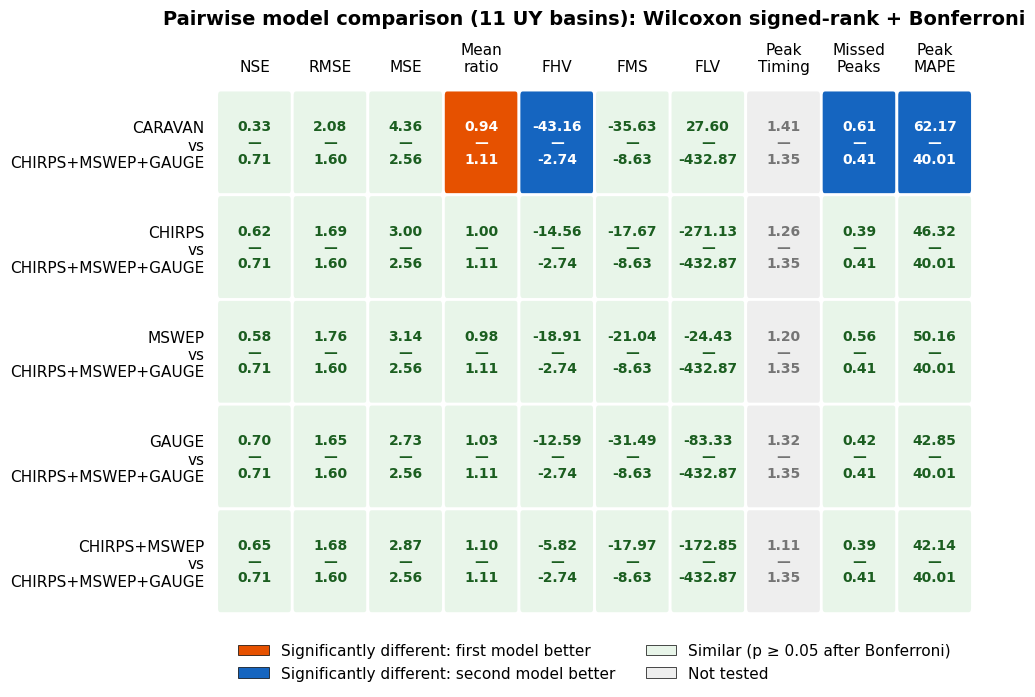

In [31]:
# ── Define models ──────────────────────────────────────────────────────────
models      = ['caravan', 'chirps', 'mswep', 'gauge', 'chirps_mswep', 'chirps_mswep_gauge'] #'chirps_gauge', 'mswep_gauge', 
short_names = ['CARAVAN', 'CHIRPS', 'MSWEP', 'GAUGE', 'CHIRPS+MSWEP',  'CHIRPS+MSWEP+GAUGE'] #'CHIRPS+GAUGE', 'MSWEP+GAUGE',

# ── Helper: get color key from posthoc_results ─────────────────────────────
skipped_metrics = [m for m, p in friedman_ps.items() if p >= 0.05]

def get_color_key(metric, m1, m2):
    res     = posthoc_results[metric]
    row     = res[(res['model_1'] == m1) & (res['model_2'] == m2)]
    flipped = False
    if row.empty:
        row     = res[(res['model_1'] == m2) & (res['model_2'] == m1)]
        flipped = True
    if row.empty:
        return 'tie'
    better = row['better'].values[0]
    if better == 'tie':
        return 'tie'
    if not flipped:
        return 'first'  if better == m1 else 'second'
    else:
        return 'first'  if better == m2 else 'second'

# ── Build plot structures ──────────────────────────────────────────────────

metrics_list = ['NSE', 'RMSE', 'MSE', 'Mean ratio', 'FHV', 'FMS', 'FLV',  
                'Peak-Timing', 'Missed-Peaks', 'Peak-MAPE']

pairs        = list(itertools.combinations(range(len(models)), 2))

# Keep only pairs involving chirps_mswep_gauge
gauge_idx = models.index('chirps_mswep_gauge')
pairs = [(i, j) for i, j in pairs if i == gauge_idx or j == gauge_idx]

pair_labels = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]


pair_labels  = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]
median_vals  = {metric: df.median() for metric, df in metric_dfs.items()}

# ── Colors ─────────────────────────────────────────────────────────────────
colors = {
    0:        '#e8f5e9',
    2:        '#eeeeee',
    'first':  '#e65100',
    'second': '#1565c0',
    'tie':    '#6a1de8',
}
text_colors = {
    0:        '#1b5e20',
    2:        '#757575',
    'first':  'white',
    'second': 'white',
    'tie':    'white',
}

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')

for m_idx, metric in enumerate(metrics_list):
    for p_idx, (i, j) in enumerate(pairs):
        m1, m2 = models[i], models[j]
        med_i  = median_vals[metric][m1]
        med_j  = median_vals[metric][m2]

        if metric in skipped_metrics:
            color_key = 2                              # Friedman n.s. → grey
        else:
            res    = posthoc_results[metric]
            row    = res[((res['model_1'] == m1) & (res['model_2'] == m2)) |
                         ((res['model_1'] == m2) & (res['model_2'] == m1))]
            is_sig = row['significant'].values[0] if not row.empty else False
            color_key = get_color_key(metric, m1, m2) if is_sig else 0

        rect = mpatches.FancyBboxPatch(
            # (p_idx - 0.45, m_idx - 0.45), 0.9, 0.9,
            (m_idx - 0.45, p_idx - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=colors[color_key],
            edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)

        label = f"{med_i:.2f}\n—\n{med_j:.2f}"
        ax.text(m_idx, p_idx, label,
                ha='center', va='center',
                fontsize=10, color=text_colors[color_key],
                fontweight='bold')


ax.set_xlim(-0.6, len(metrics_list) - 0.4)  
ax.set_ylim(len(pairs) - 0.4, -0.6)   
ax.set_xticks(range(len(metrics_list)))

metrics_list_names = ['NSE', 'RMSE', 'MSE', 'Mean\nratio', 'FHV', 'FMS', 'FLV',  
                'Peak\nTiming', 'Missed\nPeaks', 'Peak\nMAPE']

ax.set_xticklabels(metrics_list_names, fontsize=11) 
ax.set_yticks(range(len(pairs)))        
ax.set_yticklabels(pair_labels, fontsize=11)

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(facecolor=colors['first'],  label='Significantly different: first model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors['second'], label='Significantly different: second model better', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor=colors[0],        label='Similar (p ≥ 0.05 after Bonferroni)', edgecolor='black',  linewidth=0.5),
    mpatches.Patch(facecolor=colors[2],        label='Not tested', edgecolor='black',  linewidth=0.5), #not significant
]

ax.set_title(
    'Pairwise model comparison (11 UY basins): Wilcoxon signed-rank + Bonferroni',
    # 'Values show median(model 1) | median(model 2)',
    fontsize=14, pad=40, fontweight='bold'
)
ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.01), ncol=2,
          frameon=False, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.10)
# plt.savefig('wilcoxon_heatmap_us.png', dpi=150, bbox_inches='tight')